<a href="https://colab.research.google.com/github/talithanashier/H1D024098-PraktikumKB-Pertemuan7/blob/main/H1D024098_PraktikumKB_Pertemuan7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Ringkasan Arsitektur Model ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1000)           │         5,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 500)            │       500,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 300)            │       150,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 656,703 (2.51 MB)

 Trainable params: 656,703 (2.51 MB)

 Non-trainable params: 0 (0.00 B)


--- Memulai Proses Pelatihan Model ---
Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 208ms/step - accuracy: 0.5667 - loss: 1.0337 - val_accuracy: 0.7333 - val_loss: 0.6880
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 112ms/step - accuracy: 0.7167 - loss: 0.6265 - val_accuracy: 0.7667 - val_loss: 0.4690
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 137ms/step - accuracy: 0.8583 - loss: 0.4320 - val_accuracy: 0.8667 - val_loss: 0.3703
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 160ms/step - accuracy: 0.9583 - loss: 0.3303 - val_accuracy: 0.8000 - val_loss: 0.2951
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - accuracy: 0.9333 - loss: 0.2464 - val_accuracy: 0.8333 - val_loss: 0.3580
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 129ms/step - accuracy: 0.9167 - loss: 0.2441 - val_accuracy: 0.9667 - val_loss: 0.1825
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 146ms/step - accuracy: 0.9583 - loss: 0.1608 - val_accuracy: 0.9667 - val_loss: 0.1538
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 140ms/step - accuracy: 0.9500 - loss: 0

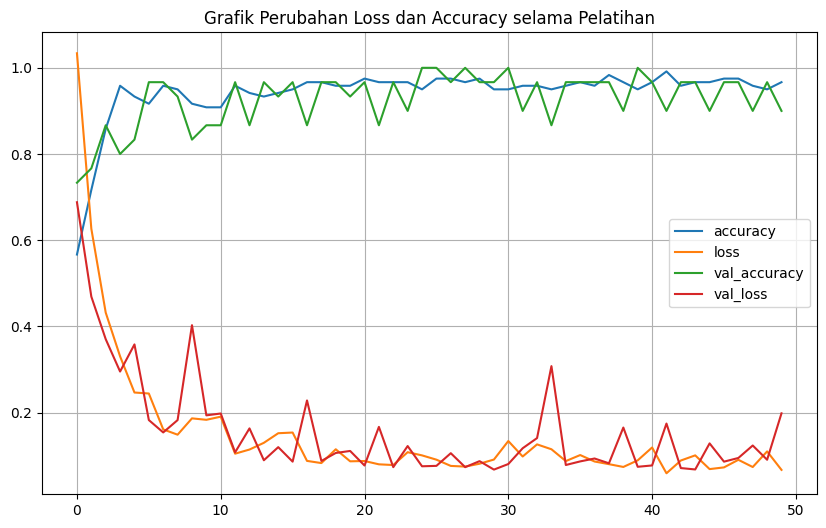

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step

Hasil Prediksi Kelas : [1 0 2 1 1 0 1 2 1 1 1 0 0 0 0 1 2 1 1 2 0 1 0 2 1 2 2 2 0 0]
Label Sebenarnya     : [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


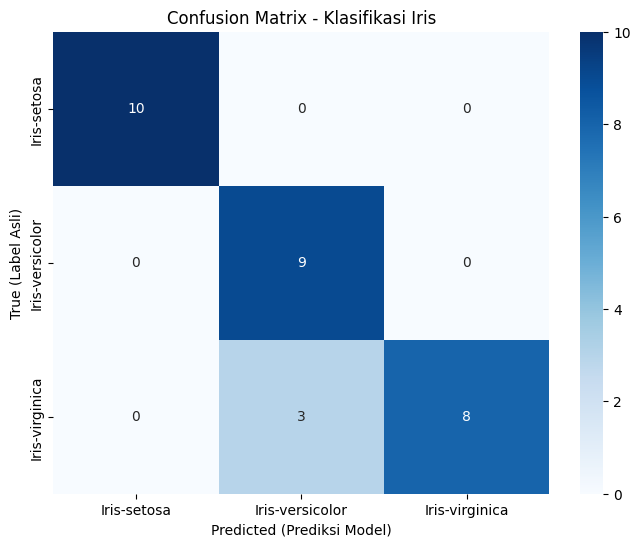

In [1]:
# ====================================================================
# 1. IMPORT LIBRARY & MODUL YANG DIPERLUKAN
# ====================================================================
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix  # Diperlukan untuk evaluasi matriks

# ====================================================================
# 2. MEMUAT DATASET IRIS LANGSUNG DARI URL
# ====================================================================
# Program mengambil langsung file iris.data secara online
url = 'http://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data'
dataset = pd.read_csv(url, header=None, sep=',')

# Memisahkan fitur (X) dan label/spesies bunga (y)
X = dataset.iloc[:, :-1].values  # 4 kolom pertama (sepal/petal length & width)
y = dataset.iloc[:, -1].values   # Kolom terakhir (nama spesies string)

# ====================================================================
# 3. MENGONVERSI LABEL STRING MENJADI ANGKA NUMERIK
# ====================================================================
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)  # Mengubah spesies menjadi angka 0, 1, atau 2

# ====================================================================
# 4. MEMBAGI DATASET MENJADI DATA LATIH & DATA UJI (Rasio 80:20)
# ====================================================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ====================================================================
# 5. MEMBANGUN ARSITEKTUR MODEL JST
# ====================================================================
model = Sequential([
    Input(shape=X_train.shape[1:]),          # Layer Input penampung 4 fitur
    Dense(1000, activation='relu'),          # Layer Tersembunyi 1 (1000 neuron)
    Dense(500, activation='relu'),           # Layer Tersembunyi 2 (500 neuron)
    Dense(300, activation='relu'),           # Layer Tersembunyi 3 (300 neuron)
    Dense(3, activation='softmax')           # Layer Output (3 neuron untuk 3 spesies)
])

print("--- Ringkasan Arsitektur Model ---")
model.summary()

# ====================================================================
# 6. KOMPILASI MODEL (COMPILE)
# ====================================================================
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ====================================================================
# 7. PROSES PELATIHAN MODEL (FIT)
# ====================================================================
print("\n--- Memulai Proses Pelatihan Model ---")
history = model.fit(
    X_train, y_train,
    epochs=50,                  # Melakukan pelatihan sebanyak 50 kali perulangan
    batch_size=32,
    validation_data=(X_test, y_test)
)

# ====================================================================
# 8. EVALUASI AKURASI MODEL
# ====================================================================
print("\n--- Hasil Evaluasi Model ---")
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Loss Akhir: {loss:.4f}")
print(f"Akurasi Akhir: {accuracy:.4f}")

# ====================================================================
# 9. VISUALISASI GRAFIK ACCURACY & LOSS
# ====================================================================
pd.DataFrame(history.history).plot(figsize=(10,6))
plt.title('Grafik Perubahan Loss dan Accuracy selama Pelatihan')
plt.grid(True)
plt.show()

# ====================================================================
# 10. MENAMPILKAN HASIL PREDIKSI VS LABEL ASLI
# ====================================================================
predictions = model.predict(X_test)
predicted_classes = predictions.argmax(axis=1)

print("\nHasil Prediksi Kelas :", predicted_classes)
print("Label Sebenarnya     :", y_test)

# ====================================================================
# 11. MEMBUAT DAN VISUALISASI CONFUSION MATRIX
# ====================================================================
cm = confusion_matrix(y_test, predicted_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.xlabel('Predicted (Prediksi Model)')
plt.ylabel('True (Label Asli)')
plt.title('Confusion Matrix - Klasifikasi Iris')
plt.show()